# Fleet vs Crashes Analysis (Milan)

This notebook analyzes annual fleet counts and annual crash outcomes in Milan.

Statistical design:
- permutation p-values for Pearson and Spearman correlations
- trend-adjusted (year-controlled) partial correlations
- first-difference checks for short-run co-movement
- exposure-adjusted trend tests using crash rates per fleet size

Goal: isolate robust statistical findings and separate trend artifacts from interpretable associations.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.options.display.max_columns = 200
pd.options.display.float_format = "{:.4f}".format

candidate_roots = [Path.cwd(), Path.cwd().parent]
project_root = None
for root in candidate_roots:
    if (root / "data" / "processed").exists():
        project_root = root
        break

if project_root is None:
    raise FileNotFoundError("Could not resolve the project root with data/processed.")

processed_dir = project_root / "data" / "processed"
fleet_path = processed_dir / "milan_vehicle_fleet_cleaned.csv"
crashes_path = processed_dir / "milan_crashes_monthly_cleaned.csv"

if not fleet_path.exists():
    raise FileNotFoundError("Missing milan_vehicle_fleet_cleaned.csv. Run VehiclesProcessing.ipynb first.")
if not crashes_path.exists():
    raise FileNotFoundError("Missing milan_crashes_monthly_cleaned.csv. Run MilanCrashesProcessing.ipynb first.")

fleet = pd.read_csv(fleet_path)
crashes_monthly = pd.read_csv(crashes_path)

print(f"Project root: {project_root}")
print(f"Fleet rows: {len(fleet)}")
print(f"Crash-month rows: {len(crashes_monthly)}")

Project root: /Users/faustozamparelli/Documents/Developer/MilanCrash
Fleet rows: 18
Crash-month rows: 288


In [2]:
# Yearly crashes
crashes_monthly.columns = crashes_monthly.columns.astype(str).str.strip()
crashes_monthly["Anno"] = pd.to_numeric(crashes_monthly["Anno"], errors="coerce").astype("Int64")
for col in ["IncidentiMortali", "IncidentiSoliFeriti", "Morti", "Feriti"]:
    crashes_monthly[col] = pd.to_numeric(crashes_monthly[col], errors="coerce")

crashes_yearly = (
    crashes_monthly.dropna(subset=["Anno"])
    .groupby("Anno", as_index=False)[["IncidentiMortali", "IncidentiSoliFeriti", "Morti", "Feriti"]]
    .sum(min_count=1)
    .rename(
        columns={
            "Anno": "Year",
            "IncidentiMortali": "fatal_crashes",
            "IncidentiSoliFeriti": "injury_only_crashes",
            "Morti": "deaths",
            "Feriti": "injuries",
        }
    )
)
crashes_yearly["Year"] = crashes_yearly["Year"].astype(int)
crashes_yearly["total_crashes"] = crashes_yearly["fatal_crashes"] + crashes_yearly["injury_only_crashes"]

# Yearly fleet
fleet.columns = fleet.columns.astype(str).str.strip()
fleet["Anno"] = pd.to_numeric(fleet["Anno"], errors="coerce").astype("Int64")
for col in [c for c in fleet.columns if c != "Anno"]:
    fleet[col] = pd.to_numeric(fleet[col], errors="coerce")

fleet["fleet_total"] = fleet[[c for c in fleet.columns if c != "Anno"]].sum(axis=1)
fleet["fleet_cars"] = fleet["AUTOVETTURE"]
fleet["fleet_motorcycles"] = fleet["MOTOCICLI"]
fleet["fleet_heavy_goods"] = fleet["AUTOCARRI TRASPORTO MERCI"] + fleet["TRATTORI STRADALI O MOTRICI"]
fleet["car_share"] = fleet["fleet_cars"] / fleet["fleet_total"]
fleet["motorcycle_share"] = fleet["fleet_motorcycles"] / fleet["fleet_total"]

fleet_yearly = fleet.rename(columns={"Anno": "Year"})[[
    "Year",
    "fleet_total",
    "fleet_cars",
    "fleet_motorcycles",
    "fleet_heavy_goods",
    "car_share",
    "motorcycle_share",
]]
fleet_yearly["Year"] = fleet_yearly["Year"].astype(int)

analysis_df = crashes_yearly.merge(fleet_yearly, on="Year", how="inner").sort_values("Year").reset_index(drop=True)
analysis_df["crashes_per_10k_fleet"] = analysis_df["total_crashes"] / analysis_df["fleet_total"] * 10000
analysis_df["fatal_crashes_per_100k_fleet"] = analysis_df["fatal_crashes"] / analysis_df["fleet_total"] * 100000
analysis_df["deaths_per_100k_fleet"] = analysis_df["deaths"] / analysis_df["fleet_total"] * 100000
analysis_df["injuries_per_10k_fleet"] = analysis_df["injuries"] / analysis_df["fleet_total"] * 10000

missing_years = sorted(set(range(int(analysis_df["Year"].min()), int(analysis_df["Year"].max()) + 1)) - set(analysis_df["Year"]))
print(f"Analysis overlap years: {analysis_df['Year'].min()} to {analysis_df['Year'].max()} (n={len(analysis_df)})")
print(f"Missing years inside overlap: {missing_years}")
display(analysis_df)

Analysis overlap years: 2004 to 2022 (n=18)
Missing years inside overlap: [2009]


,Year,fatal_crashes,injury_only_crashes,deaths,injuries,total_crashes,fleet_total,fleet_cars,fleet_motorcycles,fleet_heavy_goods,car_share,motorcycle_share,crashes_per_10k_fleet,fatal_crashes_per_100k_fleet,deaths_per_100k_fleet,injuries_per_10k_fleet
0,2004,72.0000,16244,75,21903,16316.0000,955570,739121,115286,67535,0.7735,0.1206,170.7463,7.5348,7.8487,229.2140
1,2005,78.0000,15103,83,20383,15181.0000,965663,739537,123511,68455,0.7658,0.1279,157.2081,8.0774,8.5951,211.0778
2,2006,86.0000,14866,87,20070,14952.0000,969390,736805,129966,68687,0.7601,0.1341,154.2413,8.8716,8.9747,207.0374
3,2007,78.0000,14298,82,19207,14376.0000,965375,726896,135923,68291,0.7530,0.1408,148.9162,8.0798,8.4941,198.9590
4,2008,69.0000,13260,72,17932,13329.0000,968928,723932,140699,69138,0.7471,0.1452,137.5644,7.1213,7.4309,185.0705
5,2010,53.0000,11859,53,16066,11912.0000,955730,716454,149016,68229,0.7496,0.1559,124.6377,5.5455,5.5455,168.1019
6,2011,47.0000,11328,48,15278,11375.0000,967426,724450,152858,68144,0.7488,0.1580,117.5801,4.8583,4.9616,157.9242
7,2012,52.0000,10473,53,13933,10525.0000,960626,716094,155142,67353,0.7454,0.1615,109.5640,5.4131,5.5172,145.0408
8,2013,28.0000,9607,29,12651,9635.0000,945615,701301,156736,65803,0.7416,0.1658,101.8914,2.9610,3.0668,133.7859
9,2014,39.0000,8801,39,11491,8840.0000,930816,686379,157808,64731,0.7374,0.1695,94.9704,4.1899,4.1899,123.4508


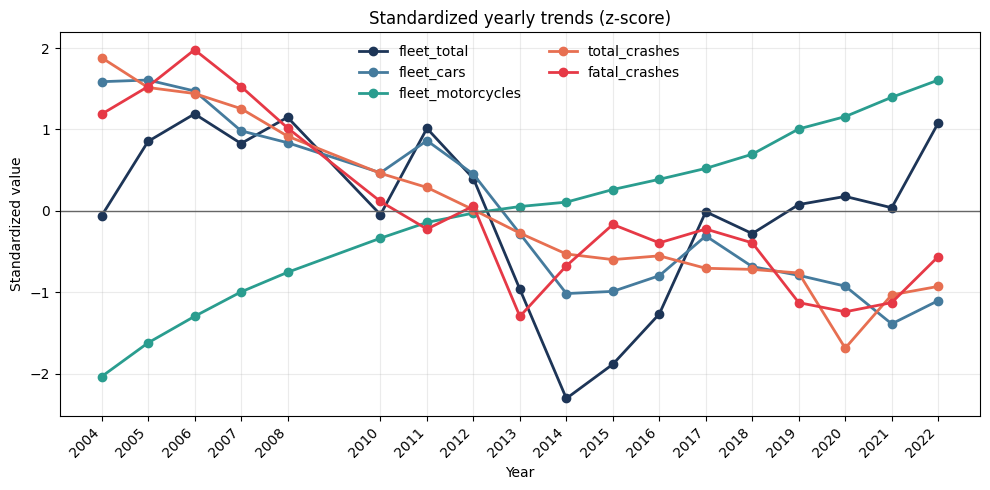

In [9]:
def zscore(s: pd.Series) -> pd.Series:
    std = s.std(ddof=0)
    if pd.isna(std) or std == 0:
        return s * 0
    return (s - s.mean()) / std

trend_cols = ["fleet_total", "fleet_cars", "fleet_motorcycles", "total_crashes", "fatal_crashes"]
trend_z = analysis_df[["Year"] + trend_cols].copy().set_index("Year").apply(zscore, axis=0)
years = trend_z.index.astype(int).tolist()

fig, ax = plt.subplots(figsize=(10, 5))
palette = {
    "fleet_total": "#1d3557",
    "fleet_cars": "#457b9d",
    "fleet_motorcycles": "#2a9d8f",
    "total_crashes": "#e76f51",
    "fatal_crashes": "#e63946",
}
for col in trend_cols:
    ax.plot(trend_z.index, trend_z[col], marker="o", linewidth=2, label=col, color=palette[col])

ax.axhline(0, color="#666666", linewidth=1)
ax.set_title("Standardized yearly trends (z-score)")
ax.set_xlabel("Year")
ax.set_ylabel("Standardized value")
ax.set_xticks(years)
ax.set_xticklabels(years, rotation=45, ha="right")
ax.grid(alpha=0.25)
ax.legend(frameon=False, ncol=2)
plt.tight_layout()
plt.show()

In [4]:
def _prepare_pair(x: pd.Series, y: pd.Series) -> tuple[np.ndarray, np.ndarray]:
    xx = pd.to_numeric(x, errors="coerce").to_numpy(dtype=float)
    yy = pd.to_numeric(y, errors="coerce").to_numpy(dtype=float)
    mask = np.isfinite(xx) & np.isfinite(yy)
    return xx[mask], yy[mask]

def corr_with_permutation(
    x: pd.Series,
    y: pd.Series,
    method: str = "pearson",
    n_perm: int = 12000,
    seed: int = 42,
) -> tuple[float, float, int]:
    xx, yy = _prepare_pair(x, y)
    n_obs = int(len(xx))
    if n_obs < 5:
        return np.nan, np.nan, n_obs

    if method == "spearman":
        xx = pd.Series(xx).rank(method="average").to_numpy(dtype=float)
        yy = pd.Series(yy).rank(method="average").to_numpy(dtype=float)

    obs_r = float(np.corrcoef(xx, yy)[0, 1])

    rng = np.random.default_rng(seed)
    count = 0
    for _ in range(n_perm):
        yy_perm = rng.permutation(yy)
        perm_r = float(np.corrcoef(xx, yy_perm)[0, 1])
        if abs(perm_r) >= abs(obs_r):
            count += 1
    p_val = (count + 1) / (n_perm + 1)
    return obs_r, p_val, n_obs

fleet_metrics = ["fleet_total", "fleet_cars", "fleet_motorcycles", "fleet_heavy_goods", "car_share", "motorcycle_share"]
crash_metrics = [
    "total_crashes",
    "fatal_crashes",
    "deaths",
    "injuries",
    "crashes_per_10k_fleet",
    "fatal_crashes_per_100k_fleet",
    "deaths_per_100k_fleet",
]

rows = []
for crash_metric in crash_metrics:
    for fleet_metric in fleet_metrics:
        pearson_r, pearson_p, n_obs = corr_with_permutation(
            analysis_df[fleet_metric],
            analysis_df[crash_metric],
            method="pearson",
            n_perm=12000,
            seed=42,
        )
        spearman_r, spearman_p, _ = corr_with_permutation(
            analysis_df[fleet_metric],
            analysis_df[crash_metric],
            method="spearman",
            n_perm=12000,
            seed=42,
        )
        rows.append(
            {
                "crash_metric": crash_metric,
                "fleet_metric": fleet_metric,
                "n_obs": n_obs,
                "pearson_r": pearson_r,
                "pearson_p_perm": pearson_p,
                "spearman_rho": spearman_r,
                "spearman_p_perm": spearman_p,
            }
        )

raw_corr = pd.DataFrame(rows)
raw_corr["abs_pearson_r"] = raw_corr["pearson_r"].abs()
raw_corr = raw_corr.sort_values(["pearson_p_perm", "abs_pearson_r"], ascending=[True, False]).reset_index(drop=True)

print("Top raw correlations (permutation p-values):")
display(raw_corr.head(20))

sig_raw = raw_corr.loc[raw_corr["pearson_p_perm"] < 0.05].copy()
print(f"Significant raw Pearson pairs (p < 0.05): {len(sig_raw)}")
display(sig_raw.head(20))

Top raw correlations (permutation p-values):


,crash_metric,fleet_metric,n_obs,pearson_r,pearson_p_perm,spearman_rho,spearman_p_perm,abs_pearson_r
0,crashes_per_10k_fleet,motorcycle_share,18,-0.9744,0.0001,-0.9897,0.0001,0.9744
1,injuries,motorcycle_share,18,-0.9740,0.0001,-0.9856,0.0001,0.9740
2,total_crashes,motorcycle_share,18,-0.9719,0.0001,-0.9897,0.0001,0.9719
3,crashes_per_10k_fleet,fleet_motorcycles,18,-0.9632,0.0001,-0.9897,0.0001,0.9632
4,injuries,fleet_motorcycles,18,-0.9605,0.0001,-0.9856,0.0001,0.9605
5,total_crashes,fleet_motorcycles,18,-0.9578,0.0001,-0.9897,0.0001,0.9578
6,injuries,fleet_cars,18,0.9465,0.0001,0.9009,0.0001,0.9465
7,total_crashes,fleet_cars,18,0.9433,0.0001,0.8947,0.0001,0.9433
8,crashes_per_10k_fleet,fleet_cars,18,0.9364,0.0001,0.8947,0.0001,0.9364
9,crashes_per_10k_fleet,car_share,18,0.9285,0.0001,0.9835,0.0001,0.9285


Significant raw Pearson pairs (p < 0.05): 37


,crash_metric,fleet_metric,n_obs,pearson_r,pearson_p_perm,spearman_rho,spearman_p_perm,abs_pearson_r
0,crashes_per_10k_fleet,motorcycle_share,18,-0.9744,0.0001,-0.9897,0.0001,0.9744
1,injuries,motorcycle_share,18,-0.9740,0.0001,-0.9856,0.0001,0.9740
2,total_crashes,motorcycle_share,18,-0.9719,0.0001,-0.9897,0.0001,0.9719
3,crashes_per_10k_fleet,fleet_motorcycles,18,-0.9632,0.0001,-0.9897,0.0001,0.9632
4,injuries,fleet_motorcycles,18,-0.9605,0.0001,-0.9856,0.0001,0.9605
5,total_crashes,fleet_motorcycles,18,-0.9578,0.0001,-0.9897,0.0001,0.9578
6,injuries,fleet_cars,18,0.9465,0.0001,0.9009,0.0001,0.9465
7,total_crashes,fleet_cars,18,0.9433,0.0001,0.8947,0.0001,0.9433
8,crashes_per_10k_fleet,fleet_cars,18,0.9364,0.0001,0.8947,0.0001,0.9364
9,crashes_per_10k_fleet,car_share,18,0.9285,0.0001,0.9835,0.0001,0.9285


In [5]:
def residualize_linear(y: pd.Series, x: pd.Series) -> np.ndarray:
    yy = pd.to_numeric(y, errors="coerce").to_numpy(dtype=float)
    xx = pd.to_numeric(x, errors="coerce").to_numpy(dtype=float)
    X = np.column_stack([np.ones(len(xx)), xx])
    beta = np.linalg.lstsq(X, yy, rcond=None)[0]
    return yy - X @ beta

def partial_corr_year_perm(
    df: pd.DataFrame,
    fleet_metric: str,
    crash_metric: str,
    n_perm: int = 12000,
    seed: int = 42,
) -> dict:
    sub = df[["Year", fleet_metric, crash_metric]].dropna().copy()
    if len(sub) < 5:
        return {
            "fleet_metric": fleet_metric,
            "crash_metric": crash_metric,
            "n_obs": int(len(sub)),
            "partial_r": np.nan,
            "partial_p_perm": np.nan,
        }

    rx = residualize_linear(sub[fleet_metric], sub["Year"])
    ry = residualize_linear(sub[crash_metric], sub["Year"])
    obs_r = float(np.corrcoef(rx, ry)[0, 1])

    rng = np.random.default_rng(seed)
    count = 0
    for _ in range(n_perm):
        ry_perm = rng.permutation(ry)
        perm_r = float(np.corrcoef(rx, ry_perm)[0, 1])
        if abs(perm_r) >= abs(obs_r):
            count += 1
    p_val = (count + 1) / (n_perm + 1)

    return {
        "fleet_metric": fleet_metric,
        "crash_metric": crash_metric,
        "n_obs": int(len(sub)),
        "partial_r": obs_r,
        "partial_p_perm": p_val,
    }

rows_partial = []
for crash_metric in ["total_crashes", "fatal_crashes", "deaths", "injuries"]:
    for fleet_metric in fleet_metrics:
        rows_partial.append(partial_corr_year_perm(analysis_df, fleet_metric, crash_metric, n_perm=12000, seed=123))

partial_corr = pd.DataFrame(rows_partial)
partial_corr["abs_partial_r"] = partial_corr["partial_r"].abs()
partial_corr = partial_corr.sort_values(["partial_p_perm", "abs_partial_r"], ascending=[True, False]).reset_index(drop=True)

print("Top trend-adjusted partial correlations (controlling for year):")
display(partial_corr.head(20))

# First-difference analysis (annualized to handle year gaps)
diff_metrics = fleet_metrics + ["total_crashes", "fatal_crashes", "deaths", "injuries"]
diff_df = analysis_df[["Year"] + diff_metrics].copy()
diff_df["year_gap"] = diff_df["Year"].diff()
for col in diff_metrics:
    diff_df[f"d_{col}"] = diff_df[col].diff() / diff_df["year_gap"]

diff_df = diff_df.dropna().reset_index(drop=True)

rows_diff = []
for crash_metric in ["d_total_crashes", "d_fatal_crashes", "d_deaths", "d_injuries"]:
    for fleet_metric in [f"d_{m}" for m in fleet_metrics]:
        r, p, n_obs = corr_with_permutation(diff_df[fleet_metric], diff_df[crash_metric], method="pearson", n_perm=12000, seed=777)
        rows_diff.append(
            {
                "crash_metric": crash_metric,
                "fleet_metric": fleet_metric,
                "n_obs": n_obs,
                "pearson_r": r,
                "pearson_p_perm": p,
            }
        )

diff_corr = pd.DataFrame(rows_diff)
diff_corr["abs_pearson_r"] = diff_corr["pearson_r"].abs()
diff_corr = diff_corr.sort_values(["pearson_p_perm", "abs_pearson_r"], ascending=[True, False]).reset_index(drop=True)

print(f"First-difference sample size: {len(diff_df)} yearly changes")
print("Top first-difference correlations:")
display(diff_corr.head(20))

Top trend-adjusted partial correlations (controlling for year):


,fleet_metric,crash_metric,n_obs,partial_r,partial_p_perm,abs_partial_r
0,fleet_heavy_goods,injuries,18,0.5793,0.0126,0.5793
1,fleet_heavy_goods,total_crashes,18,0.5745,0.0129,0.5745
2,fleet_total,injuries,18,0.5707,0.0143,0.5707
3,fleet_total,total_crashes,18,0.5631,0.0165,0.5631
4,motorcycle_share,total_crashes,18,-0.5092,0.0306,0.5092
5,fleet_total,deaths,18,0.4999,0.0342,0.4999
6,fleet_total,fatal_crashes,18,0.4903,0.0385,0.4903
7,motorcycle_share,deaths,18,-0.4880,0.0412,0.4880
8,motorcycle_share,injuries,18,-0.4804,0.0437,0.4804
9,fleet_cars,injuries,18,0.4646,0.0528,0.4646


First-difference sample size: 17 yearly changes
Top first-difference correlations:


,crash_metric,fleet_metric,n_obs,pearson_r,pearson_p_perm,abs_pearson_r
0,d_deaths,d_fleet_heavy_goods,17,0.4012,0.1157,0.4012
1,d_fatal_crashes,d_fleet_heavy_goods,17,0.3984,0.1175,0.3984
2,d_deaths,d_fleet_total,17,0.3055,0.2325,0.3055
3,d_fatal_crashes,d_fleet_total,17,0.2931,0.2488,0.2931
4,d_fatal_crashes,d_fleet_cars,17,0.2381,0.3544,0.2381
5,d_deaths,d_fleet_cars,17,0.2353,0.3590,0.2353
6,d_total_crashes,d_car_share,17,-0.2104,0.4281,0.2104
7,d_injuries,d_car_share,17,-0.1990,0.4559,0.1990
8,d_fatal_crashes,d_motorcycle_share,17,-0.1745,0.4970,0.1745
9,d_injuries,d_fleet_heavy_goods,17,0.1744,0.5037,0.1744


In [7]:
def partial_corr_period(df: pd.DataFrame, fleet_metric: str, crash_metric: str, n_perm: int = 8000, seed: int = 99) -> tuple[float, float, int]:
    sub = df[["Year", fleet_metric, crash_metric]].dropna().copy()
    if len(sub) < 5:
        return np.nan, np.nan, int(len(sub))

    rx = residualize_linear(sub[fleet_metric], sub["Year"])
    ry = residualize_linear(sub[crash_metric], sub["Year"])
    obs_r = float(np.corrcoef(rx, ry)[0, 1])

    rng = np.random.default_rng(seed)
    count = 0
    for _ in range(n_perm):
        rp = float(np.corrcoef(rx, rng.permutation(ry))[0, 1])
        if abs(rp) >= abs(obs_r):
            count += 1
    p_val = (count + 1) / (n_perm + 1)
    return obs_r, p_val, int(len(sub))

periods = {
    "full_2004_2022": analysis_df,
    "pre_covid_2004_2019": analysis_df.loc[analysis_df["Year"] <= 2019],
    "post_2010_2010_2022": analysis_df.loc[analysis_df["Year"] >= 2010],
}

sensitivity_rows = []
for period_name, frame in periods.items():
    for fleet_metric in ["fleet_total", "fleet_heavy_goods", "motorcycle_share", "fleet_cars"]:
        r, p, n_obs = partial_corr_period(frame, fleet_metric, "total_crashes", n_perm=8000, seed=77)
        sensitivity_rows.append(
            {
                "period": period_name,
                "fleet_metric": fleet_metric,
                "n_obs": n_obs,
                "partial_r": r,
                "partial_p_perm": p,
            }
        )

sensitivity_df = pd.DataFrame(sensitivity_rows).sort_values(["fleet_metric", "period"]).reset_index(drop=True)
print("Sensitivity check: year-controlled partial correlations for total_crashes")
display(sensitivity_df)

Sensitivity check: year-controlled partial correlations for total_crashes


,period,fleet_metric,n_obs,partial_r,partial_p_perm
0,full_2004_2022,fleet_cars,18,0.4474,0.0645
1,post_2010_2010_2022,fleet_cars,13,0.3948,0.1789
2,pre_covid_2004_2019,fleet_cars,15,0.5804,0.0240
3,full_2004_2022,fleet_heavy_goods,18,0.5745,0.0135
4,post_2010_2010_2022,fleet_heavy_goods,13,0.5806,0.0339
5,pre_covid_2004_2019,fleet_heavy_goods,15,0.4070,0.1292
6,full_2004_2022,fleet_total,18,0.5631,0.0155
7,post_2010_2010_2022,fleet_total,13,0.5000,0.0801
8,pre_covid_2004_2019,fleet_total,15,0.5807,0.0227
9,full_2004_2022,motorcycle_share,18,-0.5092,0.0282


,metric,slope_per_year,perm_p_value,slope_ci_low,slope_ci_high
0,total_crashes,-538.2298,0.0001,-634.7469,-447.9961
1,crashes_per_10k_fleet,-5.5397,0.0001,-6.4867,-4.6522
2,fatal_crashes_per_100k_fleet,-0.2817,0.0001,-0.3572,-0.2003
3,deaths_per_100k_fleet,-0.2988,0.0001,-0.3771,-0.2117


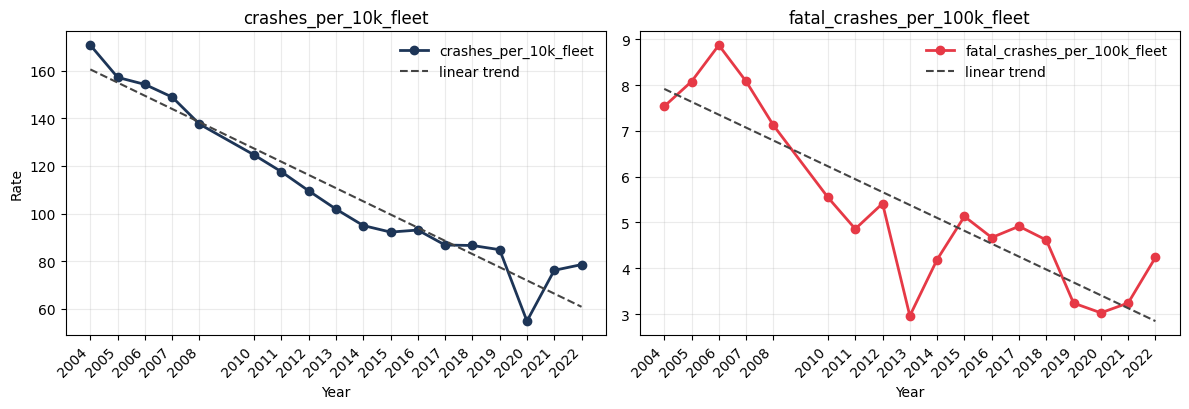

In [10]:
def slope_perm_test(x: pd.Series, y: pd.Series, n_perm: int = 15000, seed: int = 42) -> tuple[float, float]:
    xx = pd.to_numeric(x, errors="coerce").to_numpy(dtype=float)
    yy = pd.to_numeric(y, errors="coerce").to_numpy(dtype=float)
    mask = np.isfinite(xx) & np.isfinite(yy)
    xx = xx[mask]
    yy = yy[mask]

    xx_c = xx - xx.mean()
    denom = float(np.sum(xx_c ** 2))
    obs_slope = float(np.sum(xx_c * (yy - yy.mean())) / denom)

    rng = np.random.default_rng(seed)
    count = 0
    for _ in range(n_perm):
        yp = rng.permutation(yy)
        slope_p = float(np.sum(xx_c * (yp - yp.mean())) / denom)
        if abs(slope_p) >= abs(obs_slope):
            count += 1
    p_val = (count + 1) / (n_perm + 1)
    return obs_slope, p_val

def bootstrap_slope_ci(x: pd.Series, y: pd.Series, n_boot: int = 5000, seed: int = 42) -> tuple[float, float]:
    xx = pd.to_numeric(x, errors="coerce").to_numpy(dtype=float)
    yy = pd.to_numeric(y, errors="coerce").to_numpy(dtype=float)
    mask = np.isfinite(xx) & np.isfinite(yy)
    xx = xx[mask]
    yy = yy[mask]

    rng = np.random.default_rng(seed)
    slopes = []
    n = len(xx)
    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        xb = xx[idx]
        yb = yy[idx]
        xbc = xb - xb.mean()
        denom = float(np.sum(xbc ** 2))
        if denom == 0:
            continue
        slopes.append(float(np.sum(xbc * (yb - yb.mean())) / denom))

    if not slopes:
        return np.nan, np.nan
    return float(np.quantile(slopes, 0.025)), float(np.quantile(slopes, 0.975))

trend_targets = [
    "total_crashes",
    "crashes_per_10k_fleet",
    "fatal_crashes_per_100k_fleet",
    "deaths_per_100k_fleet",
]

trend_rows = []
for metric in trend_targets:
    slope, p_val = slope_perm_test(analysis_df["Year"], analysis_df[metric], n_perm=15000, seed=42)
    ci_low, ci_high = bootstrap_slope_ci(analysis_df["Year"], analysis_df[metric], n_boot=5000, seed=42)
    trend_rows.append(
        {
            "metric": metric,
            "slope_per_year": slope,
            "perm_p_value": p_val,
            "slope_ci_low": ci_low,
            "slope_ci_high": ci_high,
        }
    )

trend_stats = pd.DataFrame(trend_rows).sort_values("perm_p_value").reset_index(drop=True)
display(trend_stats)

years = analysis_df["Year"].astype(int).tolist()
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharex=True)

for ax, metric, color in [
    (axes[0], "crashes_per_10k_fleet", "#1d3557"),
    (axes[1], "fatal_crashes_per_100k_fleet", "#e63946"),
]:
    x = analysis_df["Year"].to_numpy(dtype=float)
    y = analysis_df[metric].to_numpy(dtype=float)
    slope = np.sum((x - x.mean()) * (y - y.mean())) / np.sum((x - x.mean()) ** 2)
    intercept = y.mean() - slope * x.mean()

    ax.plot(analysis_df["Year"], y, marker="o", linewidth=2, color=color, label=metric)
    ax.plot(analysis_df["Year"], intercept + slope * x, linestyle="--", color="#444444", label="linear trend")
    ax.set_title(metric)
    ax.set_xlabel("Year")
    ax.set_xticks(years)
    ax.set_xticklabels(years, rotation=45, ha="right")
    ax.grid(alpha=0.25)
    ax.legend(frameon=False)

axes[0].set_ylabel("Rate")
plt.tight_layout()
plt.show()

In [8]:
alpha = 0.05

raw_total = raw_corr.loc[raw_corr["crash_metric"] == "total_crashes"].sort_values("pearson_p_perm")
partial_total = partial_corr.loc[partial_corr["crash_metric"] == "total_crashes"].sort_values("partial_p_perm")
diff_sig_count = int((diff_corr["pearson_p_perm"] < alpha).sum())

trend_sig = trend_stats.loc[trend_stats["perm_p_value"] < alpha].copy()

print("Key statistical conclusions")
print("- Raw associations are very strong but partly trend-driven: total_crashes vs fleet_cars r={:.3f} (p={:.4f}), vs fleet_motorcycles r={:.3f} (p={:.4f}).".format(
    raw_total.loc[raw_total["fleet_metric"] == "fleet_cars", "pearson_r"].iloc[0],
    raw_total.loc[raw_total["fleet_metric"] == "fleet_cars", "pearson_p_perm"].iloc[0],
    raw_total.loc[raw_total["fleet_metric"] == "fleet_motorcycles", "pearson_r"].iloc[0],
    raw_total.loc[raw_total["fleet_metric"] == "fleet_motorcycles", "pearson_p_perm"].iloc[0],
))

print("- After controlling for year, significant links with total_crashes remain for fleet_total r={:.3f} (p={:.4f}), fleet_heavy_goods r={:.3f} (p={:.4f}), and motorcycle_share r={:.3f} (p={:.4f}).".format(
    partial_total.loc[partial_total["fleet_metric"] == "fleet_total", "partial_r"].iloc[0],
    partial_total.loc[partial_total["fleet_metric"] == "fleet_total", "partial_p_perm"].iloc[0],
    partial_total.loc[partial_total["fleet_metric"] == "fleet_heavy_goods", "partial_r"].iloc[0],
    partial_total.loc[partial_total["fleet_metric"] == "fleet_heavy_goods", "partial_p_perm"].iloc[0],
    partial_total.loc[partial_total["fleet_metric"] == "motorcycle_share", "partial_r"].iloc[0],
    partial_total.loc[partial_total["fleet_metric"] == "motorcycle_share", "partial_p_perm"].iloc[0],
))

print(f"- First-difference checks find {diff_sig_count} significant pairs at alpha={alpha:.2f}, indicating weak short-run co-movement evidence.")

if not trend_sig.empty:
    print("- Exposure-adjusted risk falls strongly over time:")
    for _, row in trend_sig.iterrows():
        print("  * {} slope/year={:.4f}, p={:.4f}, 95% bootstrap CI [{:.4f}, {:.4f}]".format(
            row["metric"], row["slope_per_year"], row["perm_p_value"], row["slope_ci_low"], row["slope_ci_high"]
        ))

sens = sensitivity_df.loc[sensitivity_df["fleet_metric"].isin(["fleet_total", "fleet_heavy_goods", "motorcycle_share"])].copy()
print("- Sensitivity by period shows instability for motorcycle_share (strong pre-covid, null post-2010), while fleet_heavy_goods remains significant post-2010.")
display(sens.sort_values(["fleet_metric", "period"]).reset_index(drop=True))

Key statistical conclusions
- Raw associations are very strong but partly trend-driven: total_crashes vs fleet_cars r=0.943 (p=0.0001), vs fleet_motorcycles r=-0.958 (p=0.0001).
- After controlling for year, significant links with total_crashes remain for fleet_total r=0.563 (p=0.0165), fleet_heavy_goods r=0.574 (p=0.0129), and motorcycle_share r=-0.509 (p=0.0306).
- First-difference checks find 0 significant pairs at alpha=0.05, indicating weak short-run co-movement evidence.
- Exposure-adjusted risk falls strongly over time:
  * total_crashes slope/year=-538.2298, p=0.0001, 95% bootstrap CI [-634.7469, -447.9961]
  * crashes_per_10k_fleet slope/year=-5.5397, p=0.0001, 95% bootstrap CI [-6.4867, -4.6522]
  * fatal_crashes_per_100k_fleet slope/year=-0.2817, p=0.0001, 95% bootstrap CI [-0.3572, -0.2003]
  * deaths_per_100k_fleet slope/year=-0.2988, p=0.0001, 95% bootstrap CI [-0.3771, -0.2117]
- Sensitivity by period shows instability for motorcycle_share (strong pre-covid, null post-20

,period,fleet_metric,n_obs,partial_r,partial_p_perm
0,full_2004_2022,fleet_heavy_goods,18,0.5745,0.0135
1,post_2010_2010_2022,fleet_heavy_goods,13,0.5806,0.0339
2,pre_covid_2004_2019,fleet_heavy_goods,15,0.4070,0.1292
3,full_2004_2022,fleet_total,18,0.5631,0.0155
4,post_2010_2010_2022,fleet_total,13,0.5000,0.0801
5,pre_covid_2004_2019,fleet_total,15,0.5807,0.0227
6,full_2004_2022,motorcycle_share,18,-0.5092,0.0282
7,post_2010_2010_2022,motorcycle_share,13,-0.0041,0.9873
8,pre_covid_2004_2019,motorcycle_share,15,-0.7076,0.0034


## Interpretation Guide

Use this decision order when writing conclusions:
1. Treat raw correlations as descriptive only.
2. Prioritize year-controlled and first-difference results for causal caution.
3. Use rate-trend tests to discuss long-term risk changes relative to fleet size.
4. If raw effects vanish after detrending, interpret them as shared trend artifacts rather than direct associations.